## Install Dependencies

### Importing all the dependencies

In [ ]:
!pip install pandas seaborn matplotlib numpy scipy scikit-learn xgboost scikit-optimize bayesian-optimization

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import uniform, randint, loguniform
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from bayes_opt import BayesianOptimization
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import gc

# Regression for Thermal Stability Dataset

### Loading dataset from Github [It may take some time]

In [3]:
#https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/thermal_stability_cleaned.csv
df = pd.read_csv('https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/thermal_stability_cleaned.csv')
df.head()

,cladding_material,waveguide_width,waveguide_height,temperature_min,temperature_max,temperature_step,refractive_index_core,refractive_index_cladding,propagation_loss_min,propagation_loss_max,...,optical_power_output_max,wavelength_min,wavelength_max,simulation_model,measurement_uncertainty,waveguide_material_Polydimethylsiloxane (PDMS),waveguide_material_Polymethyl Methacrylate (PMMA),waveguide_material_SU-8,waveguide_material_Silicon Dioxide (SiO₂),waveguide_material_Silicon Nitride (Si₃N₄)
0,0,1.216288,-1.192365,1.253003,-1.255501,1,0.493670,-0.852865,1.299475,1.541624,...,1.618882,0.0,0.0,0,0.176827,-0.491241,-0.501405,1.982832,-0.499894,-0.503109
1,0,0.939236,-0.502219,-0.625370,0.949504,1,1.707225,0.507219,1.162142,0.647350,...,1.104731,0.0,0.0,0,1.292824,-0.491241,1.994394,-0.504329,-0.499894,-0.503109
2,1,0.553672,-0.966657,0.129955,-1.564260,5,1.147704,-0.241004,0.615200,1.094487,...,1.728276,0.0,0.0,1,0.953787,2.035661,-0.501405,-0.504329,-0.499894,-0.503109
3,1,0.428999,0.969225,1.257973,0.227125,1,-0.137861,0.133662,-1.241777,-1.572175,...,0.039964,0.0,0.0,1,1.448215,-0.491241,-0.501405,-0.504329,2.000425,-0.503109
4,0,-0.429863,-1.218408,-1.092479,0.463063,5,-1.343916,-1.409046,1.014062,1.160211,...,-0.251753,0.0,0.0,0,1.448215,-0.491241,-0.501405,1.982832,-0.499894,-0.503109


#### Splitting Data in Train and Test

In [4]:
# Separate features (X) and target (y)
X = df.drop(columns=["thermal_tuning_efficiency"])  # Replace "target_column" with the actual column name
y = df["thermal_tuning_efficiency"]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train: (77718, 27)
Shape of y_train: (77718,)


## Linear Regression

### Train Linear Regration (Baseline Model)

In [ ]:
# Initialize the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# Evaluation
print("\nLinear Regression Baseline Performance:")
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R² Score:", r2_score(y_test, linear_pred))


Linear Regression Baseline Performance:
MAE: 0.8650284859640683
RMSE: 0.9993443591092037
R² Score: -0.00018675399975176532


### Grid Search CV

In [ ]:
ridge = Ridge()
# Grid Search
ridge_grid_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(ridge, ridge_grid_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
ridge_grid_best = ridge_grid.best_estimator_
ridge_grid_mse = mean_squared_error(y_test, ridge_grid_best.predict(X_test))
ridge_grid_r2 = r2_score(y_test, ridge_grid_best.predict(X_test))

# Print Grid Search hyperparameters and scores
print("\nRidge Grid Search Hyperparameters and Scores:")
ridge_grid_results = pd.DataFrame(ridge_grid.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
ridge_grid_results['mean_test_score'] = -ridge_grid_results['mean_test_score']  # Convert to positive MSE
print(ridge_grid_results)

[2025-04-17 19:09:47.358] [CUML] [info] Unused keyword parameter: copy_X during cuML estimator initialization
[2025-04-17 19:09:47.358] [CUML] [info] Unused keyword parameter: max_iter during cuML estimator initialization
[2025-04-17 19:09:47.358] [CUML] [info] Unused keyword parameter: positive during cuML estimator initialization
[2025-04-17 19:09:47.358] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-04-17 19:09:47.358] [CUML] [info] Unused keyword parameter: tol during cuML estimator initialization
[2025-04-17 19:09:47.361] [CUML] [info] Unused keyword parameter: copy_X during cuML estimator initialization
[2025-04-17 19:09:47.361] [CUML] [info] Unused keyword parameter: max_iter during cuML estimator initialization
[2025-04-17 19:09:47.361] [CUML] [info] Unused keyword parameter: positive during cuML estimator initialization
[2025-04-17 19:09:47.361] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initiali

### Random Search CV

In [ ]:
# Random Search
ridge_random_params = {'alpha': np.logspace(-2, 2, 20)}
ridge_random = RandomizedSearchCV(ridge, ridge_random_params, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
ridge_random.fit(X_train, y_train)
ridge_random_best = ridge_random.best_estimator_
ridge_random_mse = mean_squared_error(y_test, ridge_random_best.predict(X_test))
ridge_random_r2 = r2_score(y_test, ridge_random_best.predict(X_test))

# Print Random Search hyperparameters and scores
print("\nRidge Random Search Hyperparameters and Scores:")
ridge_random_results = pd.DataFrame(ridge_random.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
ridge_random_results['mean_test_score'] = -ridge_random_results['mean_test_score']  # Convert to positive MSE
print(ridge_random_results)

[2025-04-17 19:09:49.835] [CUML] [info] Unused keyword parameter: copy_X during cuML estimator initialization
[2025-04-17 19:09:49.835] [CUML] [info] Unused keyword parameter: max_iter during cuML estimator initialization
[2025-04-17 19:09:49.835] [CUML] [info] Unused keyword parameter: positive during cuML estimator initialization
[2025-04-17 19:09:49.835] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-04-17 19:09:49.835] [CUML] [info] Unused keyword parameter: tol during cuML estimator initialization
[2025-04-17 19:09:49.838] [CUML] [info] Unused keyword parameter: copy_X during cuML estimator initialization
[2025-04-17 19:09:49.838] [CUML] [info] Unused keyword parameter: max_iter during cuML estimator initialization
[2025-04-17 19:09:49.838] [CUML] [info] Unused keyword parameter: positive during cuML estimator initialization
[2025-04-17 19:09:49.838] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initiali

### Bayesian Optimization

In [ ]:

# Define the cross-validation objective function
def ridge_cv(alpha, tol, max_iter):
    model = Ridge(
        alpha=alpha,
        tol=tol,
        max_iter=int(max_iter),
        solver='saga',  # Using saga to support max_iter and tol
        random_state=42
    )
    # Use negative MSE since BayesianOptimization maximizes the score
    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    return scores.mean()

# Define the search space for hyperparameters
pbounds = {
    'alpha': (0.01, 100),
    'tol': (1e-6, 1e-2),
    'max_iter': (100, 1000)
}

# Initialize Bayesian Optimization
optimizer = BayesianOptimization(
    f=ridge_cv,
    pbounds=pbounds,
    random_state=42,
)

# Run optimization: 2 initial random points, 8 iterations = 10 total
optimizer.maximize(init_points=2, n_iter=8)

# Get best hyperparameters
best_params = optimizer.max['params']
best_alpha = best_params['alpha']
best_tol = best_params['tol']
best_max_iter = int(best_params['max_iter'])

# Train final Ridge model with best params
ridge_bayes_best = Ridge(
    alpha=best_alpha,
    tol=best_tol,
    max_iter=best_max_iter,
    solver='saga',
    random_state=42
)
ridge_bayes_best.fit(X_train, y_train)

# Evaluate on test data
ridge_bayes_mse = mean_squared_error(y_test, ridge_bayes_best.predict(X_test))
ridge_bayes_r2 = r2_score(y_test, ridge_bayes_best.predict(X_test))

# Print results
print("\n🔍 Ridge Bayesian Optimization Hyperparameters and Scores:")
print(f"Best parameters: {best_params}")
print(f"Best tol: {best_tol:.6f}")
print(f"Best max_iter: {best_max_iter}")
print(f"MSE on test set: {ridge_bayes_mse:.4f}")
print(f"R² score on test set: {ridge_bayes_r2:.4f}")

# Optional: Show all search results
results_table = pd.DataFrame(optimizer.res)
results_table['MSE (CV)'] = -results_table['target']  # Convert neg MSE back to positive
print("\n📋 Bayesian Optimization Search History:")
print(results_table[['params', 'MSE (CV)']])

|   iter    |  target   |   alpha   | max_iter  |    tol    |
-------------------------------------------------------------
[2025-04-17 19:13:46.591] [CUML] [info] Unused keyword parameter: tol during cuML estimator initialization
[2025-04-17 19:13:46.591] [CUML] [info] Unused keyword parameter: max_iter during cuML estimator initialization
[2025-04-17 19:13:46.591] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-04-17 19:13:46.599] [CUML] [info] Unused keyword parameter: copy_X during cuML estimator initialization
[2025-04-17 19:13:46.599] [CUML] [info] Unused keyword parameter: max_iter during cuML estimator initialization
[2025-04-17 19:13:46.599] [CUML] [info] Unused keyword parameter: positive during cuML estimator initialization
[2025-04-17 19:13:46.599] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-04-17 19:13:46.599] [CUML] [info] Unused keyword parameter: tol during cuML estimator

### Results Comparison

In [ ]:
# Initialize the Linear Regression model as baseline
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
baseline_preds = linear_model.predict(X_test)
baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)


# Create the results DataFrame
results = pd.DataFrame({
    'Model': ['Ridge (Grid)', 'Ridge (Random)', 'Ridge (Bayes)', 'Baseline (Linear Regression)'],
    'Best Params': [ridge_grid.best_params_, ridge_random.best_params_, optimizer.max['params'], 'N/A'], # Use optimizer.max['params'] instead of ridge_bayes_best.best_params_
    'MSE': [ridge_grid_mse, ridge_random_mse, ridge_bayes_mse, baseline_mse],
    'R2': [ridge_grid_r2, ridge_random_r2, ridge_bayes_r2, baseline_r2]
})

# Style the table
print("\nPerformance Metrics:")
styled_results = results.style.format({
    'MSE': '{:.4f}',  # Format MSE to 4 decimal places
    'R2': '{:.4f}'    # Format R2 to 4 decimal places
}).set_properties(**{
    'text-align': 'center',
    'border': '1px solid black',
    'padding': '5px'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('background-color', '#f2f2f2')]}
])

display(styled_results)


Performance Metrics:


,Model,Best Params,MSE,R2
0,Ridge (Grid),{'alpha': 100.0},0.9987,-0.0002
1,Ridge (Random),{'alpha': np.float64(61.584821106602604)},0.9987,-0.0002
2,Ridge (Bayes),"{'alpha': np.float64(99.7005194649735), 'max_iter': np.float64(535.8381266431998), 'tol': np.float64(0.008349554990202625)}",0.9987,-0.0002
3,Baseline (Linear Regression),N/A,0.9987,-0.0002


<ipython-input-19-77f411d0712e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=results, palette='viridis')


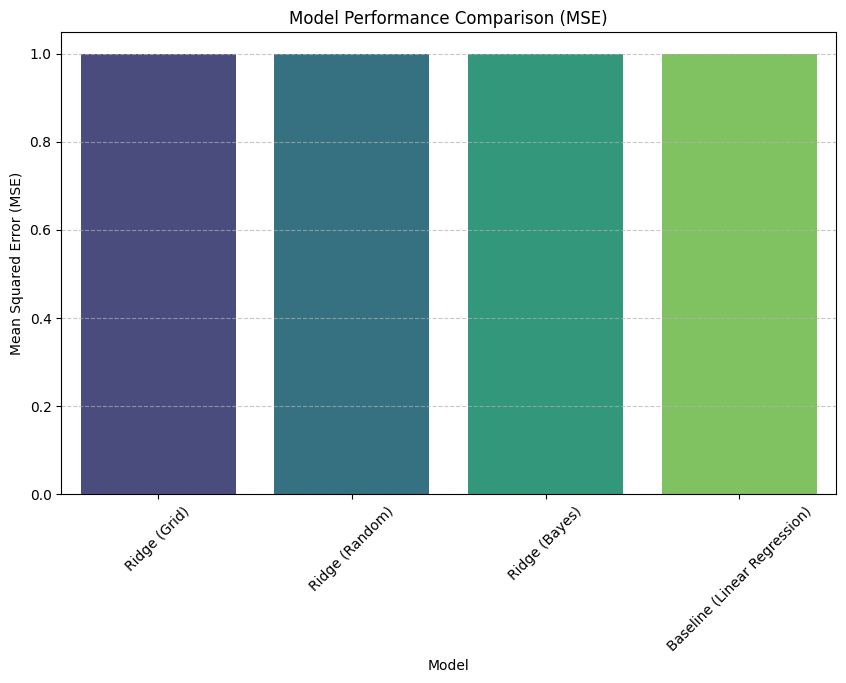

<ipython-input-19-77f411d0712e>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results, palette='viridis')


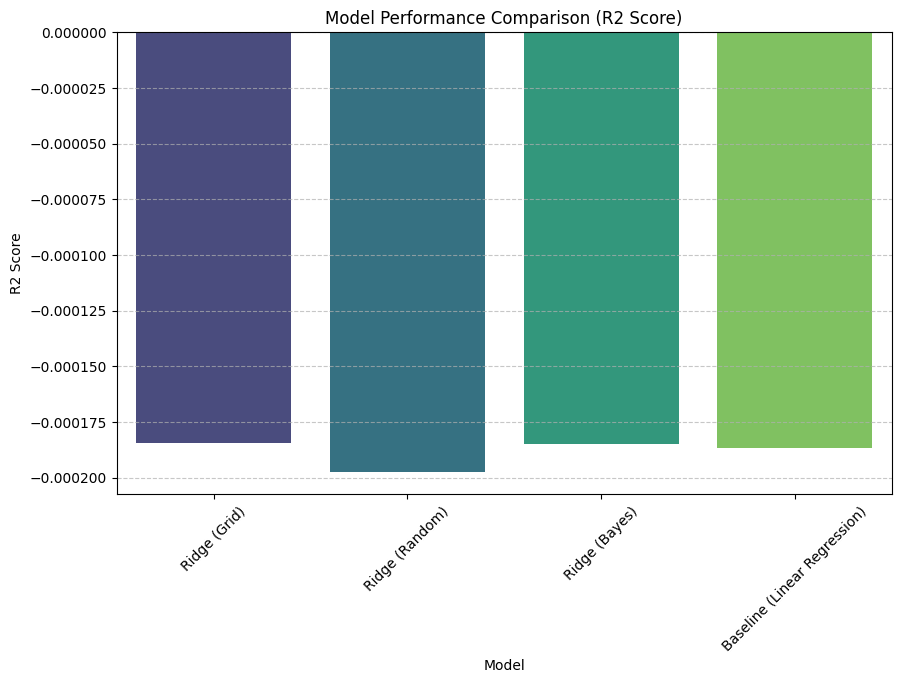

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MSE', data=results, palette='viridis')
plt.title('Model Performance Comparison (MSE)')
plt.xticks(rotation=45)
plt.ylabel('Mean Squared Error (MSE)')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=results, palette='viridis')
plt.title('Model Performance Comparison (R2 Score)')
plt.xticks(rotation=45)
plt.ylabel('R2 Score')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Random Forrest

### Train Random Forest (Baseline Model)

In [ ]:
default_model = RandomForestRegressor(random_state=42)
default_model.fit(X_train, y_train)
default_pred = default_model.predict(X_test)
# Evaluation
print("\nDefault Model Performance:")
print("MAE:", mean_absolute_error(y_test, default_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, default_pred)))
print("R² Score:", r2_score(y_test, default_pred))


Default Model Performance:
MAE: 0.8656536447797614
RMSE: 1.0006739038379704
R² Score: -0.002849855270221191


### Grid Search CV

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10.0, 20.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
print("Performing Grid Search...")
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=1)
grid_search.fit(X_train, y_train)

# Get best model
best_grid_model = grid_search.best_estimator_
grid_pred = best_grid_model.predict(X_test)

# Evaluate model performance
print("\nGrid Search Best Model Performance:")
print("Best Parameters:", grid_search.best_params_)
print("MAE:", mean_absolute_error(y_test, grid_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, grid_pred)))
print("R² Score:", r2_score(y_test, grid_pred))

Performing Grid Search...
[2025-04-17 19:53:03.075] [CUML] [info] Unused keyword parameter: ccp_alpha during cuML estimator initialization
[2025-04-17 19:53:03.075] [CUML] [info] Unused keyword parameter: monotonic_cst during cuML estimator initialization
[2025-04-17 19:53:03.079] [CUML] [info] Unused keyword parameter: ccp_alpha during cuML estimator initialization
[2025-04-17 19:53:03.079] [CUML] [info] Unused keyword parameter: monotonic_cst during cuML estimator initialization


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)



Grid Search Best Model Performance:
Best Parameters: {'max_depth': 10.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
MAE: 0.8652518428876166
RMSE: 0.9997242288859685
R² Score: -0.0009472784913224785


### Random Search CV

In [ ]:
param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [10, 20, 30],
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 5)
}
print("Performing Random Search...")
random_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist, n_iter=10, cv=3, n_jobs=1)
random_search.fit(X_train, y_train)

# Get best model
best_random_model = random_search.best_estimator_
random_pred = best_random_model.predict(X_test)

# Evaluate model performance
print("\nRandom Search Best Model Performance:")
print("Best Parameters:", random_search.best_params_)
print("MAE:", mean_absolute_error(y_test, random_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, random_pred)))
print("R² Score:", r2_score(y_test, random_pred))

Performing Random Search...

Random Search Best Model Performance:
Best Parameters: {'n_estimators': np.int64(200), 'min_samples_split': np.int64(6), 'min_samples_leaf': np.int64(1), 'max_depth': 10}
MAE: 0.8652824611512109
RMSE: 0.99971985439778
R² Score: -0.0009385188307262649


### Bayesian Optimization

In [ ]:
def rf_bo(n_estimators, max_depth):
    model = RandomForestRegressor(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=3, n_jobs=1, scoring='r2').mean()

print("Performing Bayesian Optimization...")
bo = BayesianOptimization(rf_bo, {'n_estimators': (50, 200), 'max_depth': (10, 30)})
bo.maximize(n_iter=5)

# Get best parameters
best_bo_params = bo.max['params']
best_bo_params['n_estimators'] = int(best_bo_params['n_estimators'])
best_bo_params['max_depth'] = int(best_bo_params['max_depth'])

# Train model with best parameters
best_bo_model = RandomForestRegressor(**best_bo_params, random_state=42)
best_bo_model.fit(X_train, y_train)
bo_pred = best_bo_model.predict(X_test)

# Evaluate model performance
print("\nBayesian Optimization Best Model Performance:")
print("Best Parameters:", best_bo_params)
print("MAE:", mean_absolute_error(y_test, bo_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, bo_pred)))
print("R² Score:", r2_score(y_test, bo_pred))

Performing Bayesian Optimization...
|   iter    |  target   | max_depth | n_esti... |
-------------------------------------------------


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)


| 1         | -0.007799 | 18.16     | 88.72     |


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)


| 2         | -0.001217 | 10.09     | 122.3     |


...

| 8         | -0.000948 | 10.05     | 191.0     |


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)


| 9         | -0.009252 | 29.86     | 199.3     |


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: The split criterion chosen was not present in the list of options accepted by the model and so the CRITERION_END option has been chosen.
  return init_func(self, *args, **kwargs)


| 10        | -0.000966 | 10.11     | 176.3     |

Bayesian Optimization Best Model Performance:
Best Parameters: {'max_depth': 10, 'n_estimators': 191}
MAE: 0.8653421109822221
RMSE: 0.9997211183666707
R² Score: -0.0009410498516790877


### Compare Hyperparameter Tuning Results

In [ ]:
results = pd.DataFrame({
    "Method": ["Base Line","Grid Search", "Random Search", "Bayesian Optimization"],
    "Best R² Score": [r2_score(y_test, default_pred),r2_score(y_test, grid_pred), r2_score(y_test, random_pred), r2_score(y_test, bo_pred)]
})
print(results)

                  Method  Best R² Score
0              Base Line      -0.002850
1            Grid Search      -0.000947
2          Random Search      -0.000939
3  Bayesian Optimization      -0.000941


<ipython-input-21-f52656dae016>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results["Method"], y=results["Best R² Score"], palette='viridis')


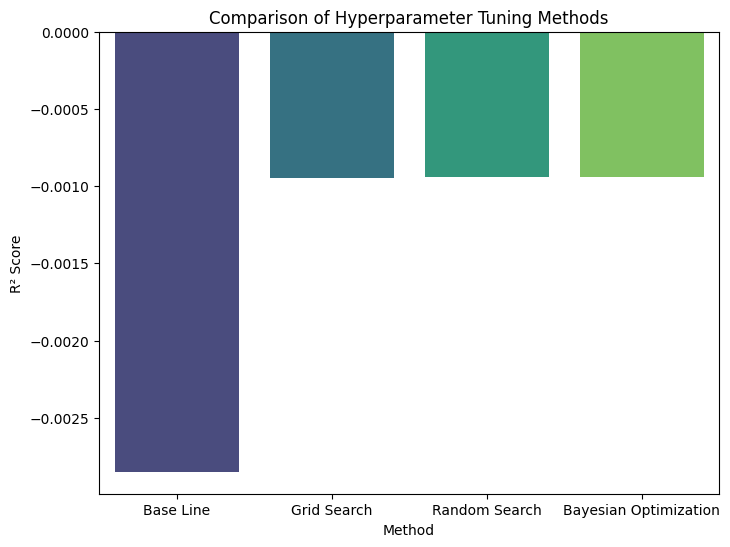

In [ ]:
# Plot results
plt.figure(figsize=(8,6))
sns.barplot(x=results["Method"], y=results["Best R² Score"], palette='viridis')
plt.title("Comparison of Hyperparameter Tuning Methods")
plt.ylabel("R² Score")
plt.show()

## XGBoost

In [ ]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluates a regression model using RMSE, MAE, and R² score.

    Parameters:
    model: Trained regression model
    X_test: Test feature set
    y_test: True target values

    Returns:
    Dictionary with RMSE, MAE, and R² score.
    """
    y_pred = model.predict(X_test)
    return {
        "RMSE": root_mean_squared_error(y_test, y_pred),  # Updated function
        "MAE": mean_absolute_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred)
    }


In [ ]:
# Create a scorer function for RMSE
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)


### Training XGBoost Model

In [ ]:

model = XGBRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Root Mean Squared Error:", np.sqrt(mse))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Root Mean Squared Error: 1.0187570600455418
Mean Absolute Error: 0.8765765648901543
R² Score: -0.039422301725907216


### Hyperparameter Tuning

### Grid Search CV

In [ ]:
xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_grid = {
    "n_estimators": [50,100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [1, 5, 7],
    'subsample': [0.3,0.5,0.7]
}

grid_search = GridSearchCV(
    estimator=xgb,                  # The model to tune
    param_grid=param_grid,           # The parameter grid we defined
    cv=5,                            # 5-fold cross-validation
    scoring= rmse_scorer ,         
    n_jobs=1,                       
    return_train_score=True        
)

grid_search.fit(X_train, y_train)

grid_results = evaluate_model(grid_search.best_estimator_, X_test, y_test)
print(grid_results)
print("Best Parameters (GridSearchCV):", grid_search.best_params_)

{'RMSE': 0.9992687800816188, 'MAE': 0.8650101992575291, 'R²': -3.5474247023215e-05}
Best Parameters (GridSearchCV): {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.5}


### Random Search CV

In [ ]:
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.7, 0.3)
}

random_search = RandomizedSearchCV(
    estimator=xgb, # The model to tune
    param_distributions=param_dist, # The parameter distribution to sample from
    n_iter=100, # The number of parameter settings that are sampled
    cv=5, # 5-fold cross-validation
    scoring=rmse_scorer, # Lower MSE is better
    n_jobs=1, # Uses all CPU cores
    random_state=42,
    return_train_score=True # Include training scores
)
random_search.fit(X_train, y_train)

random_results = evaluate_model(random_search.best_estimator_, X_test, y_test)
print(random_results)
print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)

{'RMSE': 0.999263151370651, 'MAE': 0.8650014234413755, 'R²': -2.420821950210872e-05}
Best Parameters (RandomizedSearchCV): {'learning_rate': np.float64(0.021066084206359838), 'max_depth': 3, 'n_estimators': 51, 'subsample': np.float64(0.8508037069686584)}


### Bayesian Optimization

In [ ]:

def xgb_cv(n_estimators, learning_rate, max_depth):
    # Cast integer params
    n_estimators = int(n_estimators)
    max_depth = int(max_depth)

    xgb = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    # Use negative RMSE (because bayes_opt maximizes)
    rmse_scores = cross_val_score(
        xgb, X_train, y_train,
        scoring=make_scorer(mean_squared_error, greater_is_better=False),
        cv=2
    )

    # Return mean negative RMSE
    return rmse_scores.mean()

# Define bounds
pbounds = {
    'n_estimators': (50, 300),
    'learning_rate': (0.01, 0.2),
    'max_depth': (3, 10)
}

# Run Bayesian Optimization
optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=pbounds,
    random_state=42
)

optimizer.maximize(init_points=3, n_iter=17)  # Total 20 like your BayesSearchCV

# Get best params
best_params = optimizer.max['params']
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_depth'] = int(best_params['max_depth'])

# Train final model with best hyperparameters
xgb_best = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1
)

xgb_best.fit(X_train, y_train)

# Final evaluation
y_pred = xgb_best.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = xgb_best.score(X_test, y_test)

# Results
print("\n📌 Best Parameters (Bayesian Optimization):", best_params)
print(f"✅ Final RMSE: {rmse:.4f}")
print(f"✅ R² Score: {r2:.4f}")

# Optional: Show all trials
results_table = pd.DataFrame(optimizer.res)
results_table['RMSE (CV)'] = (-results_table['target'])**0.5
print("\n📋 Bayesian Optimization Search History:")
print(results_table[['params', 'RMSE (CV)']])

|   iter    |  target   | learni... | max_depth | n_esti... |
-------------------------------------------------------------
| 1         | -1.051    | 0.08116   | 9.655     | 233.0     |
| 2         | -1.007    | 0.1237    | 4.092     | 89.0      |
| 3         | -1.012    | 0.02104   | 9.063     | 200.3     |
| 4         | -1.003    | 0.09329   | 3.118     | 87.9      |
| 5         | -1.003    | 0.1019    | 3.146     | 75.55     |
| 6         | -1.002    | 0.07908   | 3.429     | 52.88     |
| 7         | -1.021    | 0.0508    | 8.427     | 169.2     |
| 8         | -1.019    | 0.0844    | 9.939     | 63.34     |
| 9         | -1.041    | 0.1458    | 5.906     | 300.0     |
| 10        | -1.003    | 0.06296   | 3.104     | 131.9     |
| 11        | -1.032    | 0.07558   | 9.803     | 119.7     |
| 12        | -1.002    | 0.03042   | 3.201     | 142.4     |
| 13        | -1.015    | 0.1761    | 3.005     | 267.1     |
| 14        | -1.086    | 0.1698    | 9.996     | 137.6     |
| 15    

### Performance Comparison Table

In [ ]:
# 1️⃣ GridSearchCV Best Model
best_grid = grid_search.best_estimator_
y_pred_grid = best_grid.predict(X_test)
mse_grid = mean_squared_error(y_test, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
r2_grid = r2_score(y_test, y_pred_grid)

# 2️⃣ RandomizedSearchCV Best Model
best_random = random_search.best_estimator_
y_pred_random = best_random.predict(X_test)
mse_random = mean_squared_error(y_test, y_pred_random)
rmse_random = np.sqrt(mse_random)
r2_random = r2_score(y_test, y_pred_random)

# 3️⃣ Bayesian Optimization Best Model
y_pred_optuna = xgb_best.predict(X_test)
mse_optuna = mean_squared_error(y_test, y_pred_optuna)
rmse_optuna = np.sqrt(mse_optuna)
r2_optuna = r2_score(y_test, y_pred_optuna)

#  Display results
print("\n--- Model Performance Comparison ---")
print(f"GridSearchCV   -> MSE: {mse_grid:.4f}, RMSE: {rmse_grid:.4f}, R2: {r2_grid:.4f}")
print(f"RandomSearchCV -> MSE: {mse_random:.4f}, RMSE: {rmse_random:.4f}, R2: {r2_random:.4f}")
print(f"Optuna (Bayesian) -> MSE: {mse_optuna:.4f}, RMSE: {rmse_optuna:.4f}, R2: {r2_optuna:.4f}")



--- Model Performance Comparison ---
GridSearchCV   -> MSE: 0.9985, RMSE: 0.9993, R2: -0.0000
RandomSearchCV -> MSE: 0.9985, RMSE: 0.9993, R2: -0.0000
Optuna (Bayesian) -> MSE: 0.9989, RMSE: 0.9994, R2: -0.0004


In [ ]:
results = pd.DataFrame({
    'Model': ['GridSearchCV', 'RandomizedSearchCV', 'Optuna (Bayesian)'],
    'MSE': [mse_grid, mse_random, mse_optuna],
    'RMSE': [rmse_grid, rmse_random, rmse_optuna],
    'R2 Score': [r2_grid, r2_random, r2_optuna]
})

print("\n--- Comparison Table ---")
print(results)


--- Comparison Table ---
                Model       MSE      RMSE  R2 Score
0        GridSearchCV  0.998538  0.999269 -0.000035
1  RandomizedSearchCV  0.998527  0.999263 -0.000024
2   Optuna (Bayesian)  0.998852  0.999426 -0.000350


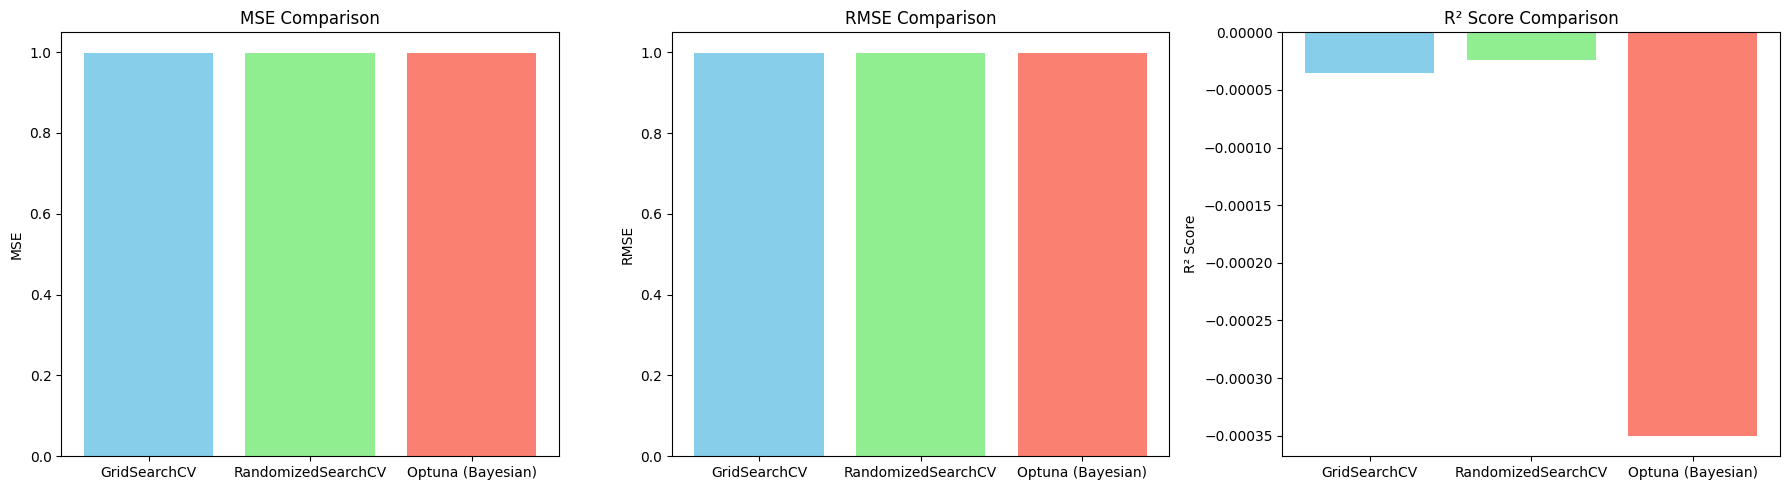

In [ ]:
# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# MSE Plot
axs[0].bar(results['Model'], results['MSE'], color=['skyblue', 'lightgreen', 'salmon'])
axs[0].set_title('MSE Comparison')
axs[0].set_ylabel('MSE')

# RMSE Plot
axs[1].bar(results['Model'], results['RMSE'], color=['skyblue', 'lightgreen', 'salmon'])
axs[1].set_title('RMSE Comparison')
axs[1].set_ylabel('RMSE')

# R2 Score Plot
axs[2].bar(results['Model'], results['R2 Score'], color=['skyblue', 'lightgreen', 'salmon'])
axs[2].set_title('R² Score Comparison')
axs[2].set_ylabel('R² Score')

plt.tight_layout()
plt.show()


## Multi Layer Perception

In [4]:
cv_results = {
    'Method': [],
    'RMSE': [],
    'MAE': [],
    'R2': []
}

In [5]:

mlp = MLPRegressor(random_state=42)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("MLP Regressor Performance:")
print("RMSE:", rmse)
print("MAE:", mae)
print(f"R^2 Score: {r2}")
cv_results['Method'].append('MLP Regressor')
cv_results['RMSE'].append(rmse)
cv_results['MAE'].append(mae)
cv_results['R2'].append(r2)

MLP Regressor Performance:
RMSE: 1.0189981803327282
MAE: 0.8773840800574806
R^2 Score: -0.03991438266040004


In [6]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu'],
    'solver': ['sgd'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['adaptive'],
    'max_iter': [500]
}

param_dist = {
    'hidden_layer_sizes': [(np.random.randint(50, 200),), (np.random.randint(50, 200), np.random.randint(50, 200))],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': loguniform(1e-4, 1e-1),
    'learning_rate': ['adaptive'],
    'max_iter': [500]
}

### Grid Search CV

In [7]:
grid_search = GridSearchCV(
  MLPRegressor(random_state=42),
  param_grid,
  scoring='neg_mean_squared_error',
  cv=3,
  n_jobs=-1,
  return_train_score=True
)
grid_search.fit(X_train, y_train)

print("Best GridSearchCV Parameters:", grid_search.best_params_)
print("Best GridSearchCV Score:", -grid_search.best_score_)
best_model_grid = grid_search.best_estimator_
y_pred_grid = best_model_grid.predict(X_test)

rmse_grid = np.sqrt(mean_squared_error(y_test, y_pred_grid))
r2_grid = r2_score(y_test, y_pred_grid)
mae_grid = mean_absolute_error(y_test, y_pred_grid)
print("GridSearchCV RMSE:", rmse_grid)
print("GridSearchCV MAE:", mae_grid)
print(f"GridSearchCV R^2 Score: {r2_grid}")
cv_results['Method'].append('MLP Regressor (Grid Search)')
cv_results['RMSE'].append(rmse_grid)
cv_results['MAE'].append(mae_grid)
cv_results['R2'].append(r2_grid)

Best GridSearchCV Parameters: {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (50,), 'learning_rate': 'adaptive', 'max_iter': 500, 'solver': 'sgd'}
Best GridSearchCV Score: 1.0029907591407856
GridSearchCV RMSE: 0.9997244279890887
GridSearchCV MAE: 0.8651842558333909
GridSearchCV R^2 Score: -0.0009476771847627408


### Random Search CV

In [8]:
random_search = RandomizedSearchCV(
    MLPRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=2,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)
random_search.fit(X_train, y_train)
print("Best RandomizedSearchCV Parameters:", random_search.best_params_)
print("Best RandomizedSearchCV Score:", -random_search.best_score_)
best_model_random = random_search.best_estimator_
y_pred_random = best_model_random.predict(X_test)
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
r2_random = r2_score(y_test, y_pred_random)
mae_random = mean_absolute_error(y_test, y_pred_random)
print("RandomizedSearchCV RMSE:", rmse_random)
print("RandomizedSearchCV MAE:", mae_random)
print(f"RandomizedSearchCV R^2 Score: {r2_random}")
cv_results['Method'].append('MLP Regressor (Random Search)')
cv_results['RMSE'].append(rmse_random)
cv_results['MAE'].append(mae_random)
cv_results['R2'].append(r2_random)

Best RandomizedSearchCV Parameters: {'activation': 'tanh', 'alpha': np.float64(0.01129013355909268), 'hidden_layer_sizes': (123,), 'learning_rate': 'adaptive', 'max_iter': 500, 'solver': 'sgd'}
Best RandomizedSearchCV Score: 1.0060611583819297
RandomizedSearchCV RMSE: 1.0003129784129925
RandomizedSearchCV MAE: 0.865846393845152
RandomizedSearchCV R^2 Score: -0.0021265652281781122


### Bayesian Optimization

In [22]:
def mlp_cv(hidden_layer_sizes, alpha):
    hidden_layer_sizes = int(hidden_layer_sizes)
    alpha = float(alpha)

    model = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_sizes,),
        alpha=alpha,
        max_iter=500,
        random_state=42
    )

    score = cross_val_score(model, X_train, y_train,
                            scoring='neg_mean_squared_error',
                            cv=2, n_jobs=-1)
    
    return score.mean()

# Parameter bounds
pbounds = {
    'hidden_layer_sizes': (50, 200),
    'alpha': (1e-4, 1e-1)
}

# Bayesian Optimization
optimizer = BayesianOptimization(
    f=mlp_cv,
    pbounds=pbounds,
    random_state=42
)

optimizer.maximize(init_points=5, n_iter=15)

# Extract best parameters
best_params = optimizer.max['params']
best_hidden = int(best_params['hidden_layer_sizes'])
best_alpha = float(best_params['alpha'])

# Train final model
final_model = MLPRegressor(
    hidden_layer_sizes=(best_hidden,),
    alpha=best_alpha,
    max_iter=500,
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    random_state=42
)

final_model.fit(X_train, y_train)
y_pred_bayes = final_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Final Evaluation Metrics:")
print("Best Parameters (Bayesian Optimization):", best_params)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")

cv_results['Method'].append('MLP Regressor (Bayesian Optimization)')
cv_results['RMSE'].append(rmse)
cv_results['MAE'].append(mae)
cv_results['R2'].append(r2)

|   iter    |  target   |   alpha   | hidden... |
-------------------------------------------------
| 1         | -1.085    | 0.03752   | 192.6     |
| 2         | -1.052    | 0.07323   | 139.8     |
| 3         | -1.041    | 0.01569   | 73.4      |
| 4         | -1.127    | 0.005903  | 179.9     |
| 5         | -1.065    | 0.06015   | 156.2     |
| 6         | -1.039    | 0.03959   | 84.89     |
| 7         | -1.049    | 0.03167   | 83.53     |
| 8         | -1.044    | 0.03102   | 92.35     |
| 9         | -1.037    | 0.02382   | 64.5      |
| 10        | -1.03     | 0.01369   | 53.65     |
| 11        | -1.053    | 0.06872   | 123.3     |
| 12        | -1.053    | 0.06363   | 109.0     |
| 13        | -1.023    | 0.08205   | 58.62     |
| 14        | -1.084    | 0.0163    | 131.7     |
| 15        | -1.094    | 0.0184    | 147.1     |
| 16        | -1.043    | 0.08102   | 100.7     |
| 17        | -1.084    | 0.002086  | 116.6     |
| 18        | -1.072    | 0.09032   | 165.2     |


### Comparison of Hyperparameter Tuning Techniques

C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_7104\173264476.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='RMSE', data=cv_df, palette='muted')


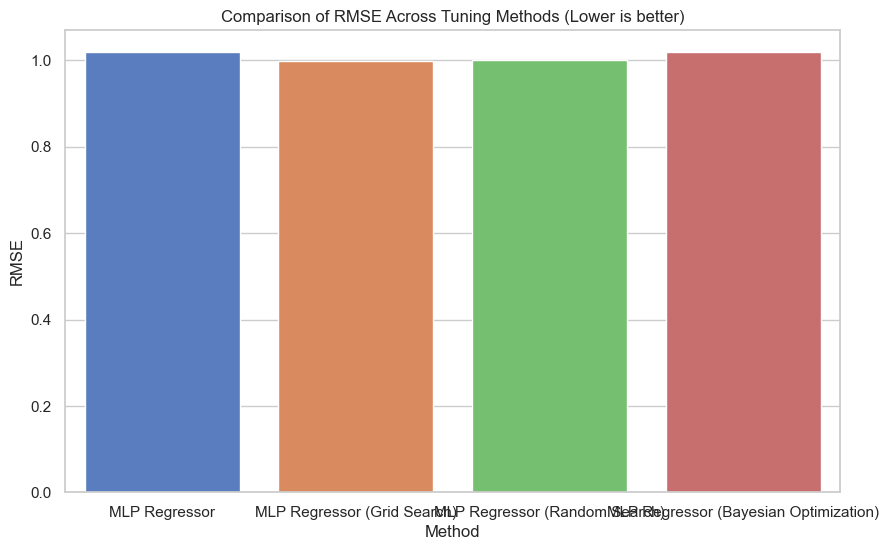

C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_7104\173264476.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='MAE', data=cv_df, palette='muted')


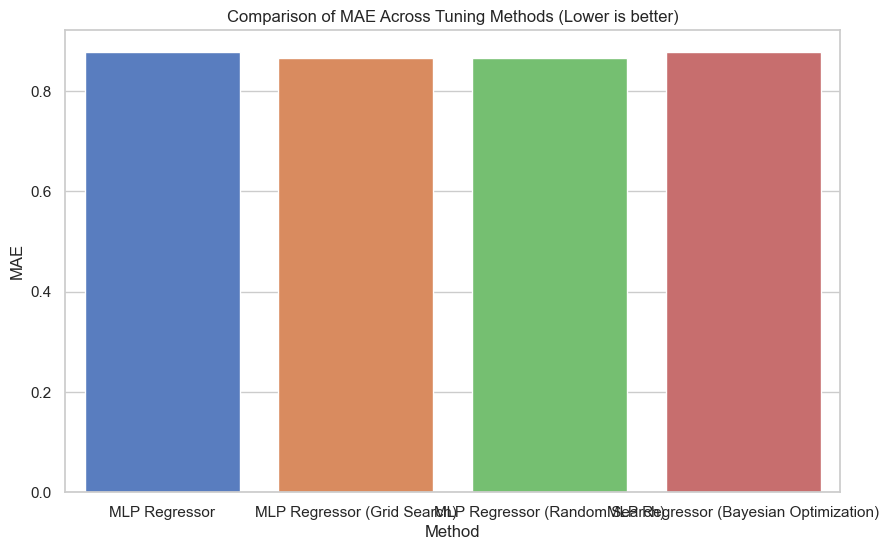

C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_7104\173264476.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='R2', data=cv_df, palette='muted')


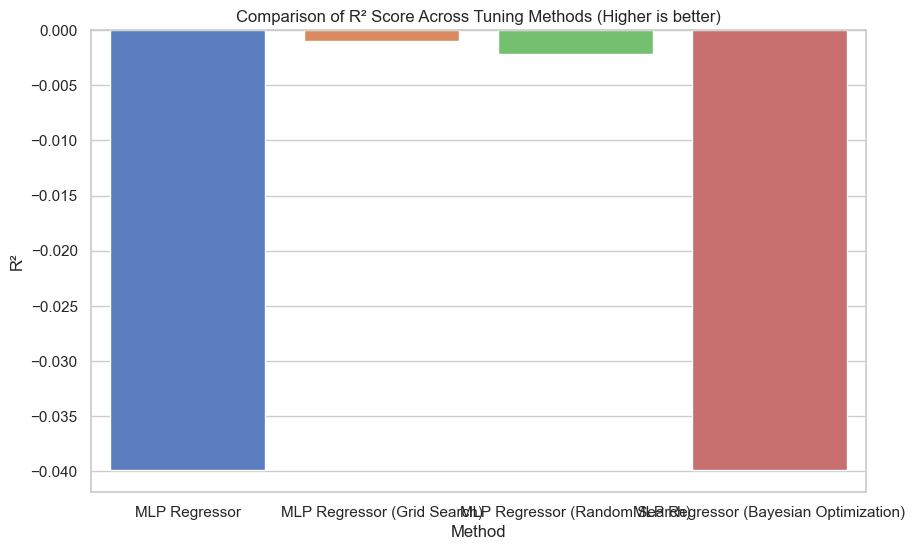

In [24]:
cv_df = pd.DataFrame(cv_results)

# Set style
sns.set_theme(style="whitegrid")

# Plot RMSE
plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='RMSE', data=cv_df, palette='muted')
plt.title('Comparison of RMSE Across Tuning Methods (Lower is better)')
plt.ylabel('RMSE')
plt.show()

# Plot MAE
plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='MAE', data=cv_df, palette='muted')
plt.title('Comparison of MAE Across Tuning Methods (Lower is better)')
plt.ylabel('MAE')
plt.show()

# Plot R²
plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='R2', data=cv_df, palette='muted')
plt.title('Comparison of R² Score Across Tuning Methods (Higher is better)')
plt.ylabel('R²')
plt.show()

In [ ]:
del grid_search
del random_search
del optimizer
del best_model_grid
del best_model_random
del final_model
del y_pred_grid
del y_pred_random
del y_pred_bayes
gc.collect()

## k-Nearest Neighbors

### Grid Search CV

In [5]:
knn = KNeighborsRegressor()
knn_grid_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(knn, knn_grid_params, cv=3, scoring='neg_mean_squared_error')
knn_grid.fit(X_train, y_train)
knn_grid_best = knn_grid.best_estimator_
knn_grid_mse = mean_squared_error(y_test, knn_grid_best.predict(X_test))
knn_grid_r2 = r2_score(y_test, knn_grid_best.predict(X_test))

# Print Grid Search hyperparameters and scores
print("\nKNN Grid Search Hyperparameters and Scores:")
knn_grid_results = pd.DataFrame(knn_grid.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_grid_results['mean_test_score'] = -knn_grid_results['mean_test_score']  # Convert to positive MSE
print(knn_grid_results)


KNN Grid Search Hyperparameters and Scores:
   param_n_neighbors param_weights  mean_test_score  std_test_score
0                  3       uniform         1.338843        0.010198
1                  3      distance         1.340608        0.010322
2                  5       uniform         1.201008        0.006032
3                  5      distance         1.202588        0.006191
4                  7       uniform         1.144241        0.006417
5                  7      distance         1.145337        0.006546
6                  9       uniform         1.112661        0.006852
7                  9      distance         1.113582        0.006938


### Random Search CV

In [6]:
# Random Search
knn_random_params = {'n_neighbors': np.arange(3, 15), 'weights': ['uniform', 'distance']}
knn_random = RandomizedSearchCV(knn, knn_random_params, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42)
knn_random.fit(X_train, y_train)
knn_random_best = knn_random.best_estimator_
knn_random_mse = mean_squared_error(y_test, knn_random_best.predict(X_test))
knn_random_r2 = r2_score(y_test, knn_random_best.predict(X_test))

# Print Random Search hyperparameters and scores
print("\nKNN Random Search Hyperparameters and Scores:")
knn_random_results = pd.DataFrame(knn_random.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_random_results['mean_test_score'] = -knn_random_results['mean_test_score']  # Convert to positive MSE
print(knn_random_results)


KNN Random Search Hyperparameters and Scores:
   param_n_neighbors param_weights  mean_test_score  std_test_score
0                  7       uniform         1.144241        0.006417
1                 11       uniform         1.092280        0.005948
2                  3       uniform         1.338843        0.010198
3                 12       uniform         1.085192        0.006755
4                  8      distance         1.127097        0.007285
5                  7      distance         1.145337        0.006546
6                  9      distance         1.113582        0.006938
7                  3      distance         1.340608        0.010322
8                 13      distance         1.077694        0.005993
9                  5      distance         1.202588        0.006191


### Bayesian Optimization

In [7]:
# Bayesian Optimization
knn_bayes_params = {'n_neighbors': (3, 15), 'weights': ['uniform', 'distance']}
knn_bayes = BayesSearchCV(knn, knn_bayes_params, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42)
knn_bayes.fit(X_train, y_train)
knn_bayes_best = knn_bayes.best_estimator_
knn_bayes_mse = mean_squared_error(y_test, knn_bayes_best.predict(X_test))
knn_bayes_r2 = r2_score(y_test, knn_bayes_best.predict(X_test))

# Print Bayesian Optimization hyperparameters and scores
print("\nKNN Bayesian Optimization Hyperparameters and Scores:")
knn_bayes_results = pd.DataFrame({
    'param_n_neighbors': knn_bayes.cv_results_['param_n_neighbors'],
    'param_weights': knn_bayes.cv_results_['param_weights'],
    'mean_test_score': -knn_bayes.cv_results_['mean_test_score'],  # Convert to positive MSE
    'std_test_score': knn_bayes.cv_results_['std_test_score']
})
print(knn_bayes_results)


KNN Bayesian Optimization Hyperparameters and Scores:
   param_n_neighbors param_weights  mean_test_score  std_test_score
0                  8      distance         1.127097        0.007285
1                 13      distance         1.077694        0.005993
2                  8      distance         1.127097        0.007285
3                 13       uniform         1.076882        0.005892
4                 13       uniform         1.076882        0.005892
5                 12      distance         1.085893        0.006797
6                 10      distance         1.102229        0.006828
7                 10      distance         1.102229        0.006828
8                 14      distance         1.072322        0.006329
9                  3      distance         1.340608        0.010322


### Results Comparison

In [8]:
results = pd.DataFrame({
    'Model': ['KNN (Grid)', 'KNN (Random)', 'KNN (Bayes)'],
    'Best Params': [knn_grid.best_params_, knn_random.best_params_, knn_bayes.best_params_],
    'MSE': [ knn_grid_mse, knn_random_mse, knn_bayes_mse],
    'R2': [knn_grid_r2, knn_random_r2, knn_bayes_r2]
})

# Style the table
print("\nPerformance Metrics:")
styled_results = results.style.format({
    'MSE': '{:.4f}',  # Format MSE to 4 decimal places
    'R2': '{:.4f}'    # Format R2 to 4 decimal places
}).set_properties(**{
    'text-align': 'center',  # Center-align text
    'border': '1px solid black',  # Add borders
    'padding': '5px'  # Add padding
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('background-color', '#f2f2f2')]}
])  # Style headers

display(styled_results)


Performance Metrics:


,Model,Best Params,MSE,R2
0,KNN (Grid),"{'n_neighbors': 9, 'weights': 'uniform'}",1.1092,-0.1108
1,KNN (Random),"{'weights': 'distance', 'n_neighbors': np.int64(13)}",1.0804,-0.0820
2,KNN (Bayes),"OrderedDict({'n_neighbors': 14, 'weights': 'distance'})",1.0741,-0.0757


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_1560\2279662525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='R2', data=results_sorted, palette='viridis')


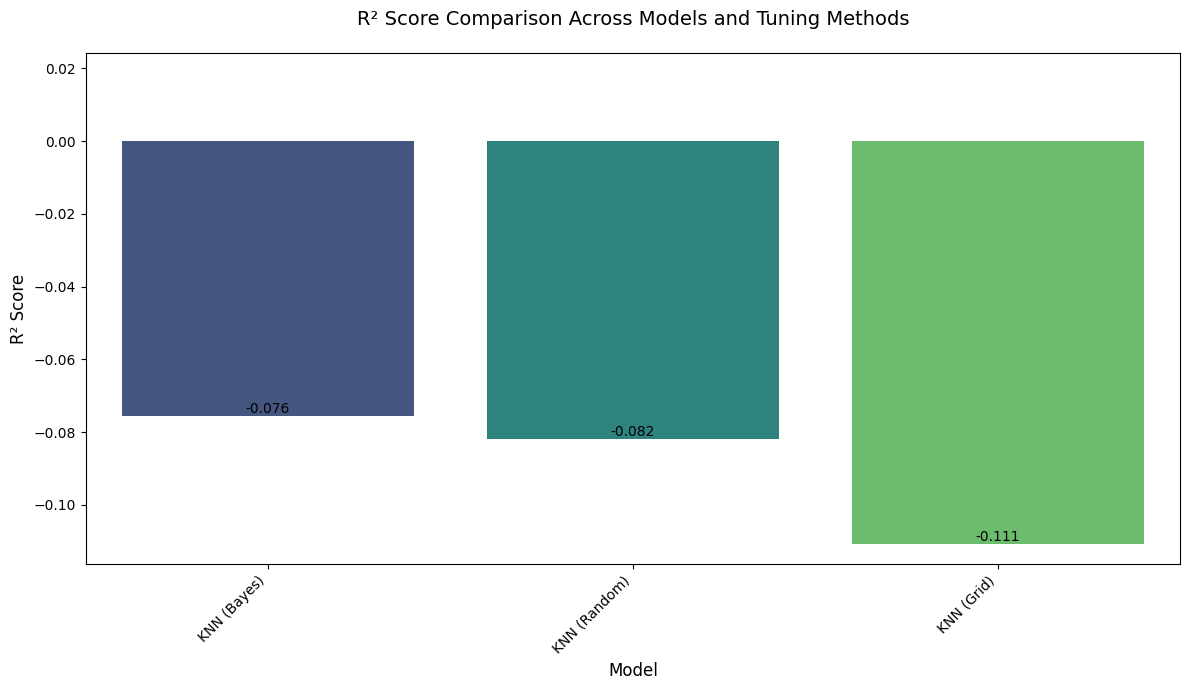

In [9]:
plt.figure(figsize=(12, 7))  # Adjusted figure size for better spacing

# Sort models by R² score descending
results_sorted = results.sort_values('R2', ascending=False)

# Create bar plot with sorted data
ax = sns.barplot(x='Model', y='R2', data=results_sorted, palette='viridis')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('R² Score Comparison Across Models and Tuning Methods', fontsize=14, pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Better alignment for rotated labels
plt.ylim(top=min(1.0, results['R2'].max() + 0.1))  # Adjust y-axis limit if needed

# Improve layout spacing
plt.tight_layout()
plt.show()

# Classification Credit Card Customer Churn Dataset

In [10]:
# https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/Customer_Churn_Classification_cleaned.csv
df = pd.read_csv('https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/Customer_Churn_Classification_cleaned.csv')
df.head()

,creditscore,age,tenure,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,france,germany,spain,female,male,tenure_age,age_tenure_product
0,668.0,33.0,3.0,2,1,0,181449.97,0,1,0,0,0,1,0.090909,99.0
1,627.0,33.0,1.0,2,1,1,49503.50,0,1,0,0,0,1,0.030303,33.0
2,678.0,40.0,10.0,2,1,0,184866.69,0,1,0,0,0,1,0.250000,400.0
3,581.0,34.0,2.0,1,1,1,84560.88,0,1,0,0,0,1,0.058824,68.0
4,716.0,33.0,5.0,2,1,1,15068.83,0,0,0,1,0,1,0.151515,165.0


## Loading data  to split

In [11]:
# Define features and target variable
X = df.drop(columns=["exited"])  # Replace "Churn" with actual target column name
y = df["exited"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression

In [12]:
print("Training baseline Logistic Regression...")
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"Baseline Accuracy: {baseline_acc:.4f}\n")

Training baseline Logistic Regression...
Baseline Accuracy: 0.8457



c:\Users\IMPERIAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Grid Search CV

In [14]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

print("Performing Grid Search...")
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, scoring='f1', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_acc = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f"Grid Search Accuracy: {grid_acc:.4f}")

Performing Grid Search...
Grid Search Accuracy: 0.8464


### Random Search CV

In [16]:
param_dist = {
    'C': np.logspace(-3, 2, 100),
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

print("Performing Random Search...")
random_search = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_distributions=param_dist, n_iter=20, cv=3, random_state=42, n_jobs=-1, scoring='f1')
random_search.fit(X_train, y_train)
random_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f"Random Search Accuracy: {random_acc:.4f}")


Performing Random Search...
Random Search Accuracy: 0.8463


### Bayesian Optimization

In [17]:
# Define the function to optimize
def bo_logistic_regression(C, max_iter, l1_ratio):
    model = LogisticRegression(
        C=C,
        max_iter=int(max_iter),
        solver='saga',               # saga supports 'elasticnet'
        penalty='elasticnet',
        l1_ratio=l1_ratio,
        random_state=42
    )
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()
    return score

# Define parameter bounds
param_bounds = {
    'C': (0.001, 10.0),
    'max_iter': (100, 1000),
    'l1_ratio': (0.0, 1.0)
}

# Run Bayesian Optimization
bo_optimizer = BayesianOptimization(
    f=bo_logistic_regression,
    pbounds=param_bounds,
    random_state=42,
    verbose=2
)

print("Running Bayesian Optimization...")
bo_optimizer.maximize(init_points=10, n_iter=30)

# Extract best parameters
best_params = bo_optimizer.max['params']
best_params['max_iter'] = int(best_params['max_iter'])

# Train final model using best parameters
best_lr = LogisticRegression(
    C=best_params['C'],
    max_iter=best_params['max_iter'],
    solver='saga',
    penalty='elasticnet',
    l1_ratio=best_params['l1_ratio'],
    random_state=42
)

best_lr.fit(X_train, y_train)
bo_predictions = best_lr.predict(X_test)

# Evaluate
bo_accuracy = accuracy_score(y_test, bo_predictions)
print(f"Bayesian Optimization Accuracy: {bo_accuracy:.4f}")


Running Bayesian Optimization...
|   iter    |  target   |     C     | l1_ratio  | max_iter  |
-------------------------------------------------------------
| 1         | 0.0       | 3.746     | 0.9507    | 758.8     |
| 2         | 0.0       | 5.987     | 0.156     | 240.4     |
| 3         | 0.0       | 0.5818    | 0.8662    | 641.0     |
| 4         | 0.0       | 7.081     | 0.02058   | 972.9     |
| 5         | 0.0       | 8.325     | 0.2123    | 263.6     |
| 6         | 0.0       | 1.835     | 0.3042    | 572.3     |
| 7         | 0.0       | 4.32      | 0.2912    | 650.7     |
| 8         | 0.0       | 1.396     | 0.2921    | 429.7     |
| 9         | 0.0       | 4.561     | 0.7852    | 279.7     |
| 10        | 0.0       | 5.143     | 0.5924    | 141.8     |
| 11        | 0.0       | 9.892     | 0.8741    | 998.0     |
| 12        | 0.0       | 0.04908   | 0.2152    | 999.2     |
| 13        | 0.0       | 8.651     | 0.3356    | 313.1     |
| 14        | 0.0       | 0.9209    |

c:\Users\IMPERIAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Comparing Models


Final Accuracy Comparison:
           Tuning Method  Accuracy
0               Baseline  0.845665
1            Grid Search  0.846378
2          Random Search  0.846316
3  Bayesian Optimization  0.799069


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_1560\4054980642.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")


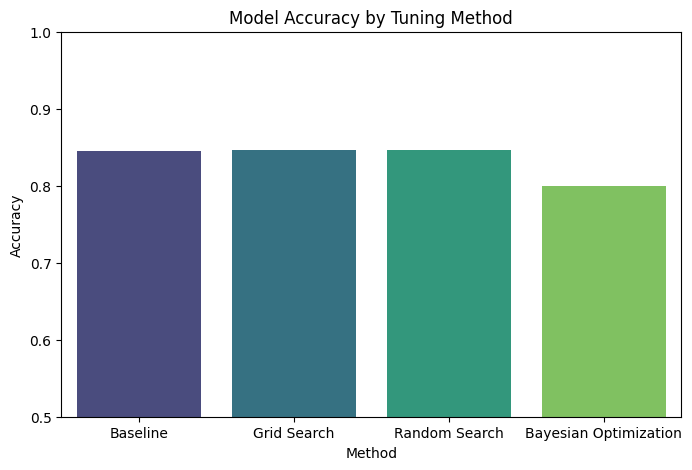

In [18]:
# Results Comparison Table
results_df = pd.DataFrame({
    "Tuning Method": ["Baseline", "Grid Search", "Random Search", "Bayesian Optimization"],
    "Accuracy": [baseline_acc, grid_acc, random_acc, bo_accuracy]
})
print("\nFinal Accuracy Comparison:")
print(results_df)

# Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy by Tuning Method")
plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.show()

## Random forrest

In [19]:
print("Training default Random Forest model...")
default_model = RandomForestClassifier(random_state=42)
default_model.fit(X_train, y_train)
default_pred = default_model.predict(X_test)
default_accuracy = accuracy_score(y_test, default_pred)
print(f"Default Model Accuracy: {default_accuracy:.4f}\n")

Training default Random Forest model...
Default Model Accuracy: 0.8477



### Grid Search CV

In [20]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
print("Performing Grid Search...")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, scoring='f1', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_accuracy = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f"Grid Search Best Accuracy: {grid_accuracy:.4f}\n")

Performing Grid Search...
Grid Search Best Accuracy: 0.8573



### Random Search CV

In [21]:
param_dist = {
    "n_estimators": np.arange(50, 300, 50),
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": np.arange(2, 11, 2),
    "min_samples_leaf": np.arange(1, 5)
}
print("Performing Random Search...")
random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=param_dist,
                                   n_iter=20, cv=3, random_state=42, n_jobs=-1, scoring='f1')
random_search.fit(X_train, y_train)
random_accuracy = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f"Random Search Best Accuracy: {random_accuracy:.4f}\n")

Performing Random Search...
Random Search Best Accuracy: 0.8600



### Bayesian Optimization

In [22]:
def rf_bo(n_estimators, max_depth, min_samples_split, min_samples_leaf):
    rf = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    scores = cross_val_score(rf, X_train, y_train, cv=3, n_jobs=-1)
    return scores.mean()
param_bounds = {
    'n_estimators': (50, 300),
    'max_depth': (5, 50),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 4),
}
bo_optimizer = BayesianOptimization(f=rf_bo, pbounds=param_bounds, random_state=42)
bo_optimizer.maximize(init_points=5, n_iter=15)

best_params_bo = bo_optimizer.max['params']
best_params_bo['n_estimators'] = int(best_params_bo['n_estimators'])
best_params_bo['max_depth'] = int(best_params_bo['max_depth'])
best_params_bo['min_samples_split'] = int(best_params_bo['min_samples_split'])
best_params_bo['min_samples_leaf'] = int(best_params_bo['min_samples_leaf'])

final_rf_bo = RandomForestClassifier(**best_params_bo, random_state=42)
final_rf_bo.fit(X_train, y_train)
bayesian_accuracy = accuracy_score(y_test, final_rf_bo.predict(X_test))

print(f"Bayesian Optimization Best Accuracy: {bayesian_accuracy:.4f}\n")

|   iter    |  target   | max_depth | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------
| 1         | 0.8574    | 21.85     | 3.852     | 7.856     | 199.7     |
| 2         | 0.8607    | 12.02     | 1.468     | 2.465     | 266.5     |
| 3         | 0.8572    | 32.05     | 3.124     | 2.165     | 292.5     |
| 4         | 0.8498    | 42.46     | 1.637     | 3.455     | 95.85     |
| 5         | 0.8571    | 18.69     | 2.574     | 5.456     | 122.8     |
| 6         | 0.8607    | 13.77     | 3.671     | 8.0       | 277.1     |
| 7         | 0.8585    | 43.95     | 3.973     | 9.92      | 249.2     |
| 8         | 0.8609    | 12.58     | 2.19      | 3.009     | 265.8     |
| 9         | 0.8461    | 5.01      | 3.515     | 9.822     | 239.0     |
| 10        | 0.8573    | 30.59     | 3.594     | 3.438     | 267.7     |
| 11        | 0.8472    | 5.197     | 3.592     | 8.836     | 298.5     |
| 12        | 0.8571    | 49.91     | 

### Comparing Models

In [23]:
results_df = pd.DataFrame({
    "Tuning Method": ["Default Model", "Grid Search", "Random Search", "Bayesian Optimization"],
    "Accuracy": [default_accuracy, grid_accuracy, random_accuracy, bayesian_accuracy]
})
print("\nFinal Comparison Table:")
print(results_df)


Final Comparison Table:
           Tuning Method  Accuracy
0          Default Model  0.847650
1            Grid Search  0.857267
2          Random Search  0.860028
3  Bayesian Optimization  0.861672


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_1560\3955685550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")


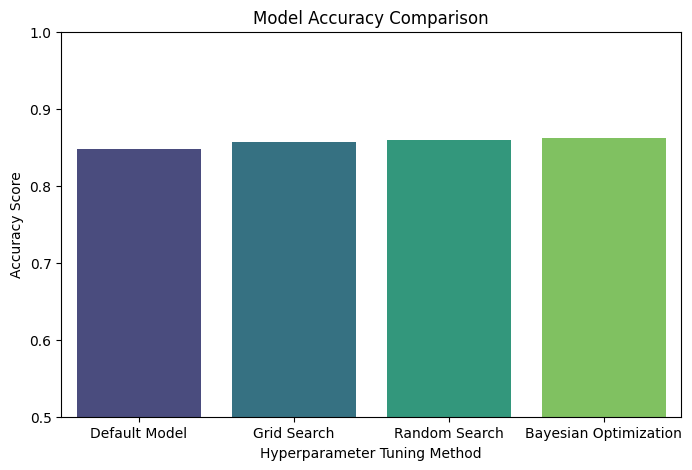

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0.5, 1.0)
plt.xlabel("Hyperparameter Tuning Method")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.show()

In [25]:
results_df = pd.DataFrame({
    "Tuning Method": ["Default Model", "Grid Search", "Random Search", "Bayesian Optimization"],
    "Accuracy": [default_accuracy, grid_accuracy, random_accuracy, bayesian_accuracy]
})
print("\nFinal Comparison Table:")
print(results_df)


Final Comparison Table:
           Tuning Method  Accuracy
0          Default Model  0.847650
1            Grid Search  0.857267
2          Random Search  0.860028
3  Bayesian Optimization  0.861672


## XGBoost Model

In [30]:
# Train the model
model = XGBClassifier(objective="binary:logistic", eval_metric="logloss")
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8608344966651156
              precision    recall  f1-score   support

           0       0.88      0.95      0.92     25758
           1       0.72      0.51      0.60      6477

    accuracy                           0.86     32235
   macro avg       0.80      0.73      0.76     32235
weighted avg       0.85      0.86      0.85     32235



### Grid Search

In [33]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

grid_search = GridSearchCV(XGBClassifier(eval_metric="logloss"), param_grid, cv=3, verbose=2, scoring='f1', n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Best Params (Grid Search):", grid_search.best_params_)
print("Best Score (Grid Search):", grid_search.best_score_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Params (Grid Search): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Score (Grid Search): 0.5942761760335378


### Random Search

In [35]:
param_dist = {
    'n_estimators': np.arange(50, 300),
    'max_depth': np.arange(3, 10, 2),
    'learning_rate': np.linspace(0.01, 0.3, 10),
}

random_search = RandomizedSearchCV(XGBClassifier(eval_metric="logloss"), param_dist, n_iter=10, verbose=2, cv=3, scoring='f1', n_jobs=-1)

random_search.fit(X_train, y_train)
print("Best Params (Random Search):", random_search.best_params_)
print("Best Score (Random Search):", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params (Random Search): {'n_estimators': np.int64(129), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.1388888888888889)}
Best Score (Random Search): 0.5934717657108409


### Bayesian Optimization

In [37]:
def xgb_eval(n_estimators, max_depth, learning_rate):
    model = XGBClassifier(n_estimators=int(n_estimators), max_depth=int(max_depth), learning_rate=learning_rate, eval_metric="logloss")

    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

optimizer = BayesianOptimization(
    f=xgb_eval,
    pbounds={'n_estimators': (50, 300), 'max_depth': (3, 10), 'learning_rate': (0.01, 0.3)},
    random_state=42,
    verbose=2  
)

optimizer.maximize(n_iter=10)
print("Best Params (Bayesian Optimization):", optimizer.max)
print("Best Score (Bayesian Optimization):", optimizer.max['target'])

|   iter    |  target   | learni... | max_depth | n_esti... |
-------------------------------------------------------------
| 1         | 0.8587    | 0.1186    | 9.655     | 233.0     |
| 2         | 0.8637    | 0.1836    | 4.092     | 89.0      |
| 3         | 0.863     | 0.02684   | 9.063     | 200.3     |
| 4         | 0.8642    | 0.2153    | 3.144     | 292.5     |
| 5         | 0.8645    | 0.2514    | 4.486     | 95.46     |
| 6         | 0.8641    | 0.21      | 5.408     | 119.3     |
| 7         | 0.854     | 0.2512    | 9.922     | 161.0     |
| 8         | 0.8584    | 0.2657    | 9.047     | 50.13     |
| 9         | 0.8518    | 0.229     | 9.964     | 272.7     |
| 10        | 0.8593    | 0.1478    | 9.96      | 107.9     |
| 11        | 0.8633    | 0.06201   | 3.175     | 129.0     |
| 12        | 0.8479    | 0.2823    | 9.656     | 300.0     |
| 13        | 0.8619    | 0.02292   | 8.925     | 92.54     |
| 14        | 0.8599    | 0.1601    | 9.213     | 124.7     |
| 15    

### Comparing Result

In [38]:
results_df = pd.DataFrame({
    "Tuning Method": ["Grid Search", "Random Search", "Bayesian Optimization"],
    "Accuracy": [grid_search.best_score_, random_search.best_score_, optimizer.max['target']]
})
print("\nFinal Comparison Table:")
print(results_df)



Final Comparison Table:
           Tuning Method  Accuracy
0            Grid Search  0.594276
1          Random Search  0.593472
2  Bayesian Optimization  0.864526


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_1560\3449290061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")


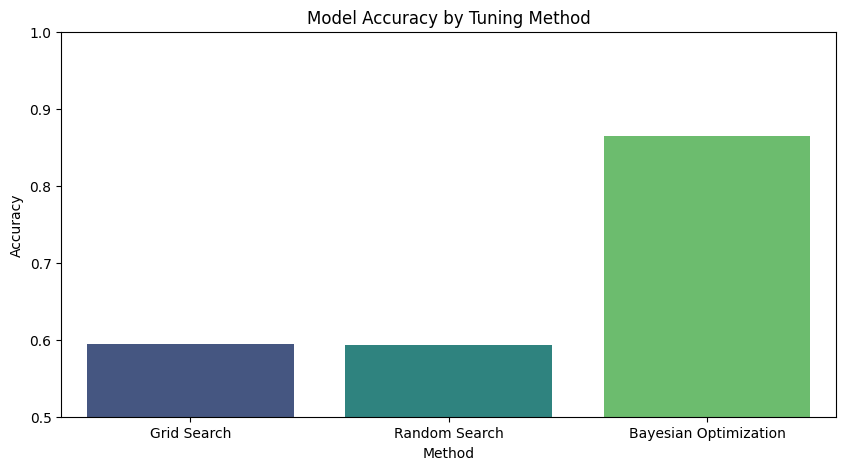

In [39]:
# Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy by Tuning Method")
plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.show()

### Final Model with Best Hyperparameters

## Multi Layer Perception

In [47]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,100), (100, 50)],
    'alpha': [0.001, 0.01, 0.1],
    'learning_rate': ['adaptive'],
    'max_iter': [500]
}

param_dist = {
    'hidden_layer_sizes': [(np.random.randint(50, 200), np.random.randint(50, 200))],
    'alpha': loguniform(1e-4, 1e-1),
    'learning_rate': ['adaptive'],
    'max_iter': [500]
}

param_bayes = {
    'hidden_layer_1': Integer(50, 200),
    'hidden_layer_2': Integer(0, 200),
    'alpha': Real(1e-4, 1e-1, prior='log-uniform'),
    'learning_rate': Categorical(['adaptive'])
}

### Grid Search CV

In [44]:
grid = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, y_train)
grid_score = grid.best_score_
print(f"GridSearchCV best score: {grid_score}")
grid_best_params = grid.best_params_
print(f"GridSearchCV best params: {grid_best_params}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
GridSearchCV best score: 0.8243743838840164
GridSearchCV best params: {'alpha': 0.001, 'hidden_layer_sizes': (100, 100), 'learning_rate': 'adaptive', 'max_iter': 500}


### Random Search CV

In [48]:
random_search = RandomizedSearchCV(
    MLPClassifier(random_state=42),
    param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)
random_search.fit(X_train, y_train)
random_score = random_search.best_score_
print(f"RandomizedSearchCV best score: {random_score}")
random_best_params = random_search.best_params_
print(f"RandomizedSearchCV best params: {random_best_params}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RandomizedSearchCV best score: 0.839016907204056
RandomizedSearchCV best params: {'alpha': np.float64(0.0007476312062252305), 'hidden_layer_sizes': (147, 124), 'learning_rate': 'adaptive', 'max_iter': 500}


### Bayesian Optimization

In [49]:
class CustomMLPClassifier(MLPClassifier):
    def set_params(self, **params):
        hl1 = params.pop('hidden_layer_1', 100)
        hl2 = params.pop('hidden_layer_2', 0)
        if hl2 > 0:
            params['hidden_layer_sizes'] = (hl1, hl2)
        else:
            params['hidden_layer_sizes'] = (hl1,)
        return super().set_params(**params)

bayes_search = BayesSearchCV(
    estimator=CustomMLPClassifier(random_state=42),
    search_spaces=param_bayes,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)
bayes_search.fit(X_train, y_train)
bayes_score = bayes_search.best_score_
print(f"BayesSearchCV best score: {bayes_score}")
bayes_best_params = bayes_search.best_params_
print(f"BayesSearchCV best params: {bayes_best_params}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

### Result Comparison

In [50]:
results_df = pd.DataFrame({
    "Tuning Method": ['GridSearchCV', 'RandomizedSearchCV', 'BayesSearchCV'],
    "Accuracy": [grid_score, random_score, bayes_score]
})
print("\nFinal Comparison Table:")
print(results_df)


Final Comparison Table:
        Tuning Method  Accuracy
0        GridSearchCV  0.824374
1  RandomizedSearchCV  0.839017
2       BayesSearchCV  0.837605


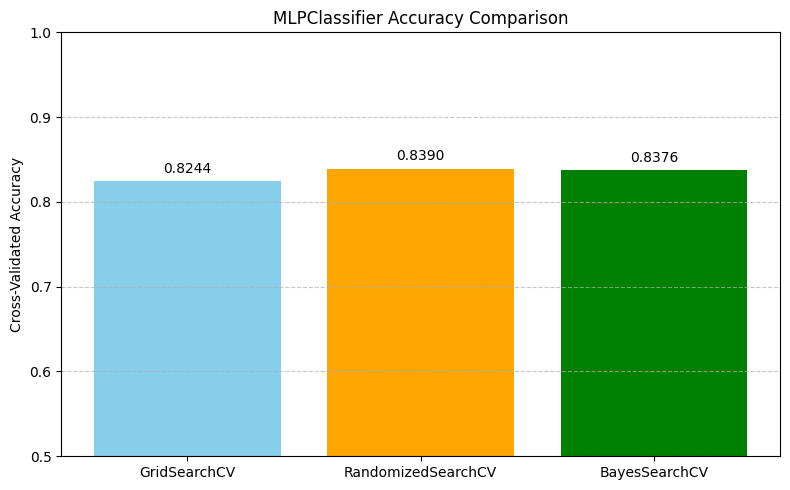

In [51]:
# Bar Chart
methods = ['GridSearchCV', 'RandomizedSearchCV', 'BayesSearchCV']
scores = [grid_score, random_score, bayes_score]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores, color=['skyblue', 'orange', 'green'])
plt.title("MLPClassifier Accuracy Comparison")
plt.ylabel("Cross-Validated Accuracy")
plt.ylim(0.5, 1.0)
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## k-Nearest Neighbors

In [52]:
print("Training default KNN model...")
default_model = KNeighborsClassifier()
default_model.fit(X_train, y_train)
default_pred = default_model.predict(X_test)
default_accuracy = accuracy_score(y_test, default_pred)
print(f"Default Model Accuracy: {default_accuracy:.4f}\n")

Training default KNN model...
Default Model Accuracy: 0.7766



### Grid Search CV

In [53]:
print("Performing Grid Search...")
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] 
}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, verbose=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_accuracy = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f"🔹 Grid Search Best Accuracy: {grid_accuracy:.4f}")
print(f"Best Parameters: {grid_search.best_params_}\n")

Performing Grid Search...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
🔹 Grid Search Best Accuracy: 0.7960
Best Parameters: {'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}



### Random Search CV

In [54]:
print("Performing Random Search...")
param_dist = {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_dist,
                                   n_iter=20, cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_accuracy = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f"🔹 Random Search Best Accuracy: {random_accuracy:.4f}")
print(f"Best Parameters: {random_search.best_params_}\n")

Performing Random Search...
🔹 Random Search Best Accuracy: 0.8002
Best Parameters: {'weights': 'uniform', 'p': 2, 'n_neighbors': np.int64(19)}



### Bayesian Optimization

In [55]:

def knn_bo(n_neighbors, p):
    # p must be 1 or 2 (Manhattan or Euclidean), weights as categorical
    params = {
        'n_neighbors': int(n_neighbors),
        'weights': 'distance' if n_neighbors > 10 else 'uniform',  # Simplified choice
        'p': int(p)
    }
    knn = KNeighborsClassifier(**params)
    scores = cross_val_score(knn, X_train, y_train, cv=3, n_jobs=-1)
    return scores.mean()

param_bounds = {
    'n_neighbors': (3, 20),
    'p': (1, 2)
}
bo_optimizer = BayesianOptimization(f=knn_bo, pbounds=param_bounds, random_state=42)
bo_optimizer.maximize(init_points=5, n_iter=15)

# Get best parameters
best_params_bo = bo_optimizer.max['params']
best_params_bo['n_neighbors'] = int(best_params_bo['n_neighbors'])
best_params_bo['p'] = int(best_params_bo['p'])
best_params_bo['weights'] = 'distance' if best_params_bo['n_neighbors'] > 10 else 'uniform'

# Train final model
final_knn_bo = KNeighborsClassifier(**best_params_bo)
final_knn_bo.fit(X_train, y_train)
bo_accuracy = accuracy_score(y_test, final_knn_bo.predict(X_test))
print(f"🔹 Bayesian Optimization Best Accuracy: {bo_accuracy:.4f}")
print(f"Best Parameters: {best_params_bo}\n")

|   iter    |  target   | n_neig... |     p     |
-------------------------------------------------
| 1         | 0.7951    | 9.367     | 1.951     |
| 2         | 0.791     | 15.44     | 1.599     |
| 3         | 0.7812    | 5.652     | 1.156     |
| 4         | 0.7613    | 3.987     | 1.866     |
| 5         | 0.7899    | 13.22     | 1.708     |
| 6         | 0.7869    | 10.85     | 1.009     |
| 7         | 0.7903    | 7.996     | 1.02      |
| 8         | 0.7919    | 18.69     | 1.991     |
| 9         | 0.7921    | 19.98     | 1.051     |
| 10        | 0.7918    | 17.25     | 1.002     |
| 11        | 0.7903    | 7.807     | 1.994     |
| 12        | 0.7917    | 16.87     | 1.994     |
| 13        | 0.7921    | 19.99     | 1.996     |
| 14        | 0.7869    | 10.8      | 1.998     |
| 15        | 0.7905    | 14.33     | 1.001     |
| 16        | 0.7951    | 9.319     | 1.007     |
| 17        | 0.7919    | 18.55     | 1.005     |
| 18        | 0.7976    | 8.937     | 1.576     |


### Performance Comparison


Final Comparison Table:
           Tuning Method  Accuracy
0          Default Model  0.776578
1            Grid Search  0.796029
2          Random Search  0.800155
3  Bayesian Optimization  0.861672


C:\Users\IMPERIAL\AppData\Local\Temp\ipykernel_1560\3264214405.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")


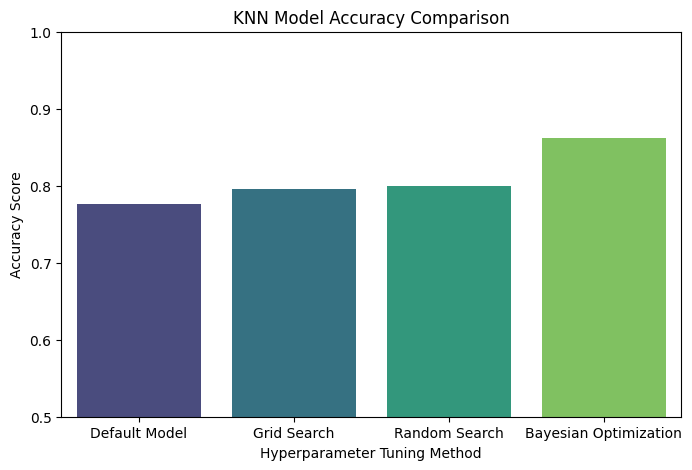

In [56]:
# Comparison table
results_df = pd.DataFrame({
    "Tuning Method": ["Default Model", "Grid Search", "Random Search", "Bayesian Optimization"],
    "Accuracy": [default_accuracy, grid_accuracy, random_accuracy, bayesian_accuracy]
})
print("\nFinal Comparison Table:")
print(results_df)

# Plot: Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x="Tuning Method", y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0.5, 1.0)
plt.xlabel("Hyperparameter Tuning Method")
plt.ylabel("Accuracy Score")
plt.title("KNN Model Accuracy Comparison")
plt.show()